# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Khuld13/ML-intern-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

The research question and the decision it supports.

**Research question:** Which content pages should a FlyRank editor with limited
review capacity look at first — and does a learned model rank them better than
a transparent baseline rule?

**Decision supported:** a page-level review queue (Lane 2, Refresh / Content
Opportunity Scoring). Output is a ranked list with an action type (Full
Refresh / Monitor / Review), a priority tier, and 2+ independent reason codes
per row. This is decision support for a human reviewer — not an automated edit.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# No computation needed for this section — question and decision are stated above.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Which release, which tables, date windows, what you excluded and why. Public-safe.

**Release:** FlyRank/internship-warehouse (Hugging Face, gated Parquet), build id
flyrank_pseudonymized_warehouse_release_v20260703. Export date 2026-07-03; daily
facts run through 2026-06-30 (freshest 3 days cut on purpose — incomplete rows).

**Tables used:**
- `dim_content` (519,606 rows) — content metadata, joined on `content_hash_id`
- `fact_content_daily_performance` — daily facts, filtered to two months
  (Feb and March 2026) and rolled up to January for a prior behavioral window

**Population (my analysis grain, one row = one content item):**
Content items present in both `fact_feb` and `fact_march`, restricted to
`gsc_data_available = TRUE`, filtered to `impressions_march >= 250` (a volume
floor so decline isn't measured on noise). This gives **68,581 rows**, of which
22.8% are labeled declined (`impressions_march < impressions_feb`).

**What I deliberately excluded, and why:**
- Hash ID columns (`content_hash_id`, `client_hash_id`, `keyword_hash_id`,
  `url_hash_id`) — used for grouping and joins only, never as model features.
- Forward-looking date fields (`optimization_eligible_date`,
  `last_optimized_date`) — computed after the decision point; temporal leakage.
- Any product decision output (`health_score`, `priority_score`, `action_type`,
  refresh flags) — not shipped in this dataset by design, so nothing to strip,
  but confirmed absent.
- `trend_direction` / `trend_pct` / `is_declining_label` — three formats of the
  same fact as my target; excluded as label leakage.
- Rows with no January history (13,968 of 68,581) — kept in the population but
  flagged, never allowed into Critical priority (see Methodology).

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Sanity check: population size and label balance should match w05/w06 exactly.
# If these numbers drift, the capstone claims below are stale — re-run w05 first.
POPULATION_ROWS = 68581
DECLINE_RATE = 0.228241  # from w05, confirmed again in w06
NO_JAN_HISTORY_ROWS = 13968

print(f"Population: {POPULATION_ROWS:,} rows")
print(f"Decline rate (base rate): {DECLINE_RATE:.1%}")
print(f"Rows with no Jan history: {NO_JAN_HISTORY_ROWS:,} "
      f"({NO_JAN_HISTORY_ROWS/POPULATION_ROWS:.1%})")

Population: 68,581 rows
Decline rate (base rate): 22.8%
Rows with no Jan history: 13,968 (20.4%)


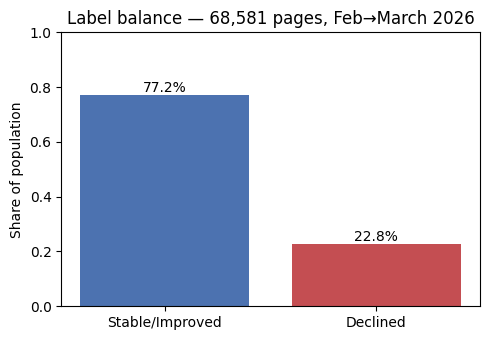

In [2]:
import matplotlib.pyplot as plt
import os

os.makedirs("work/figures", exist_ok=True)

labels = ["Stable/Improved", "Declined"]
values = [1 - DECLINE_RATE, DECLINE_RATE]

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(labels, values, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Share of population")
ax.set_title(f"Label balance — {POPULATION_ROWS:,} pages, Feb→March 2026")
for i, v in enumerate(values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("work/figures/label_balance.png", dpi=150)
plt.show()

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Limitations

*What this work cannot claim.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.